In [1]:
# Towards real-time assessment of infrasound event detection capability 
# using deep learning-based transmission loss estimation

# We provide a convolutional recurrent neural network estimating in near real-time 
# ground-level infrasound transmission loss (TL) of a given frequency over 4,000 km.

# It uses as inputs realistic range-dependent atmospheric models combining 
# horizontal wind speed and temperature fields.

In [2]:
### IMPORTs

In [ ]:
!pip install tensorflow==2.8.3
import numpy as np
from joblib import load
import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [4]:
### PARAMETERs

In [5]:
nb_lines_c_ratio_slice = 433
nb_columns_PE = 800
distance_PE = np.linspace(1., 4000., nb_columns_PE)  	  # pas de 5 km distance
altitude = np.linspace(0., 129.9, nb_lines_c_ratio_slice) # pas de 0.3 km altitude

In [6]:
### LOAD DATASETs (already standardized using scikit-learn StandardScaler() function)

In [7]:
c_ratios = np.load("Data/c_ratios_dataset_test.npy") # input dataset 1
freqs = np.load("Data/freqs_dataset_test.npy") # input dataset 2
PEs = np.load("Data/PEs_dataset_test.npy") # output dataset
print("\n2D c_ratios small test dataset: ", np.shape(c_ratios))
print("Frequencies small test dataset : ", np.shape(freqs))
print("1D PEs small test dataset : ", np.shape(PEs))


2D c_ratios small test dataset:  (100, 433, 40)
Frequencies small test dataset :  (100,)
1D PEs small test dataset :  (100, 800)


In [8]:
### LOAD MODELs (data scalers and pre-trained convolutional recurrent neural network)

In [ ]:
scaler_c_ratios = load("to_load/scaler_c_ratios.bin", mmap_mode=None)
scaler_pes = load("to_load/scaler_PEs.bin", mmap_mode=None)
cnn_gru = load_model("to_load/cnn_gru.h5")

In [10]:
### PREDICTIONs

In [11]:
def compute_horizontally_averaged_c_ratios_maxima(c_ratios, inf, sup, scaler_c_ratios):
    # De-standardize c_ratios slices                                                        
    destandardized_c_ratios = np.reshape(c_ratios, (c_ratios.shape[0], c_ratios.shape[1]*c_ratios.shape[2]))
    destandardized_c_ratios = np.reshape(scaler_c_ratios.inverse_transform(destandardized_c_ratios), (c_ratios.shape[0], c_ratios.shape[1], c_ratios.shape[2]))

    # Restrain each c_ratio slice in a specific atmospheric layer                   
    c_ratio_maxima = np.empty((c_ratios.shape[0], 1, c_ratios.shape[2]))
    horizontally_averaged_c_ratio_maxima = np.empty((c_ratios.shape[0], 1))
    for sample in range(c_ratios.shape[0]):
        for column in range(c_ratios.shape[2]):
            cmpt = 0
            c_ratios_restrained = np.empty([sup-inf,])
            for line in range(inf,sup):
                c_ratios_restrained[cmpt] = destandardized_c_ratios[sample,line,column]
                cmpt+=1
            c_ratio_maxima[sample,0,column] = np.max(c_ratios_restrained)

    # Compute horizontal mean                  
    for sample in range(c_ratios.shape[0]):
        horizontally_averaged_c_ratio_maxima[sample,:] = np.mean(c_ratio_maxima[sample,0,:])
    return horizontally_averaged_c_ratio_maxima

In [12]:
def make_testing_predictions(nb_columns_PE, distance_PE, altitude, testing_c_ratios, testing_freqs, testing_PEs, cnn_gru, scaler_c_ratios, scaler_pes):
    # Prepare testing datasets
    testing_freqs = testing_freqs[:, np.newaxis, np.newaxis]
    freqs_test = tf.repeat(testing_freqs, repeats=5, axis=1)
    horizontally_averaged_c_ratios_maxima_30_60 = compute_horizontally_averaged_c_ratios_maxima(testing_c_ratios, (np.abs(altitude-30)).argmin(), (np.abs(altitude-60)).argmin(), scaler_c_ratios) 
 
    # Make testing predictions
    nb_samples = testing_c_ratios.shape[0]
    predicted_TLs = np.empty((nb_samples, testing_PEs.shape[1]))
    PE_simulations = np.empty((nb_samples, testing_PEs.shape[1]))
    for sample in range(nb_samples):
        # Make a prediction (destandardized)
        c_ratio = (testing_c_ratios[sample]).reshape(1, testing_c_ratios.shape[1], testing_c_ratios.shape[2])
        freq = np.reshape(freqs_test[sample], (1, 5, 1))
        prediction = np.reshape(np.array((cnn_gru([c_ratio, freq]))), (1, nb_columns_PE))
        destandardized_prediction = (scaler_pes.inverse_transform(prediction)).reshape(nb_columns_PE,) 
        predicted_TLs[sample] = destandardized_prediction

        # Get the associated PE simulation (destandardized)
        PE = testing_PEs[sample].reshape(1, nb_columns_PE)
        destandardized_PE = scaler_pes.inverse_transform(PE).reshape(nb_columns_PE,)	
        PE_simulations[sample] = destandardized_PE

    return horizontally_averaged_c_ratios_maxima_30_60, freqs_test, predicted_TLs, PE_simulations


horizontally_averaged_c_ratios_maxima_30_60, freqs_test, predicted_TLs, PE_simulations = make_testing_predictions(nb_columns_PE, distance_PE, altitude, c_ratios, freqs, PEs, cnn_gru, scaler_c_ratios, scaler_pes)

In [13]:
### PLOTs

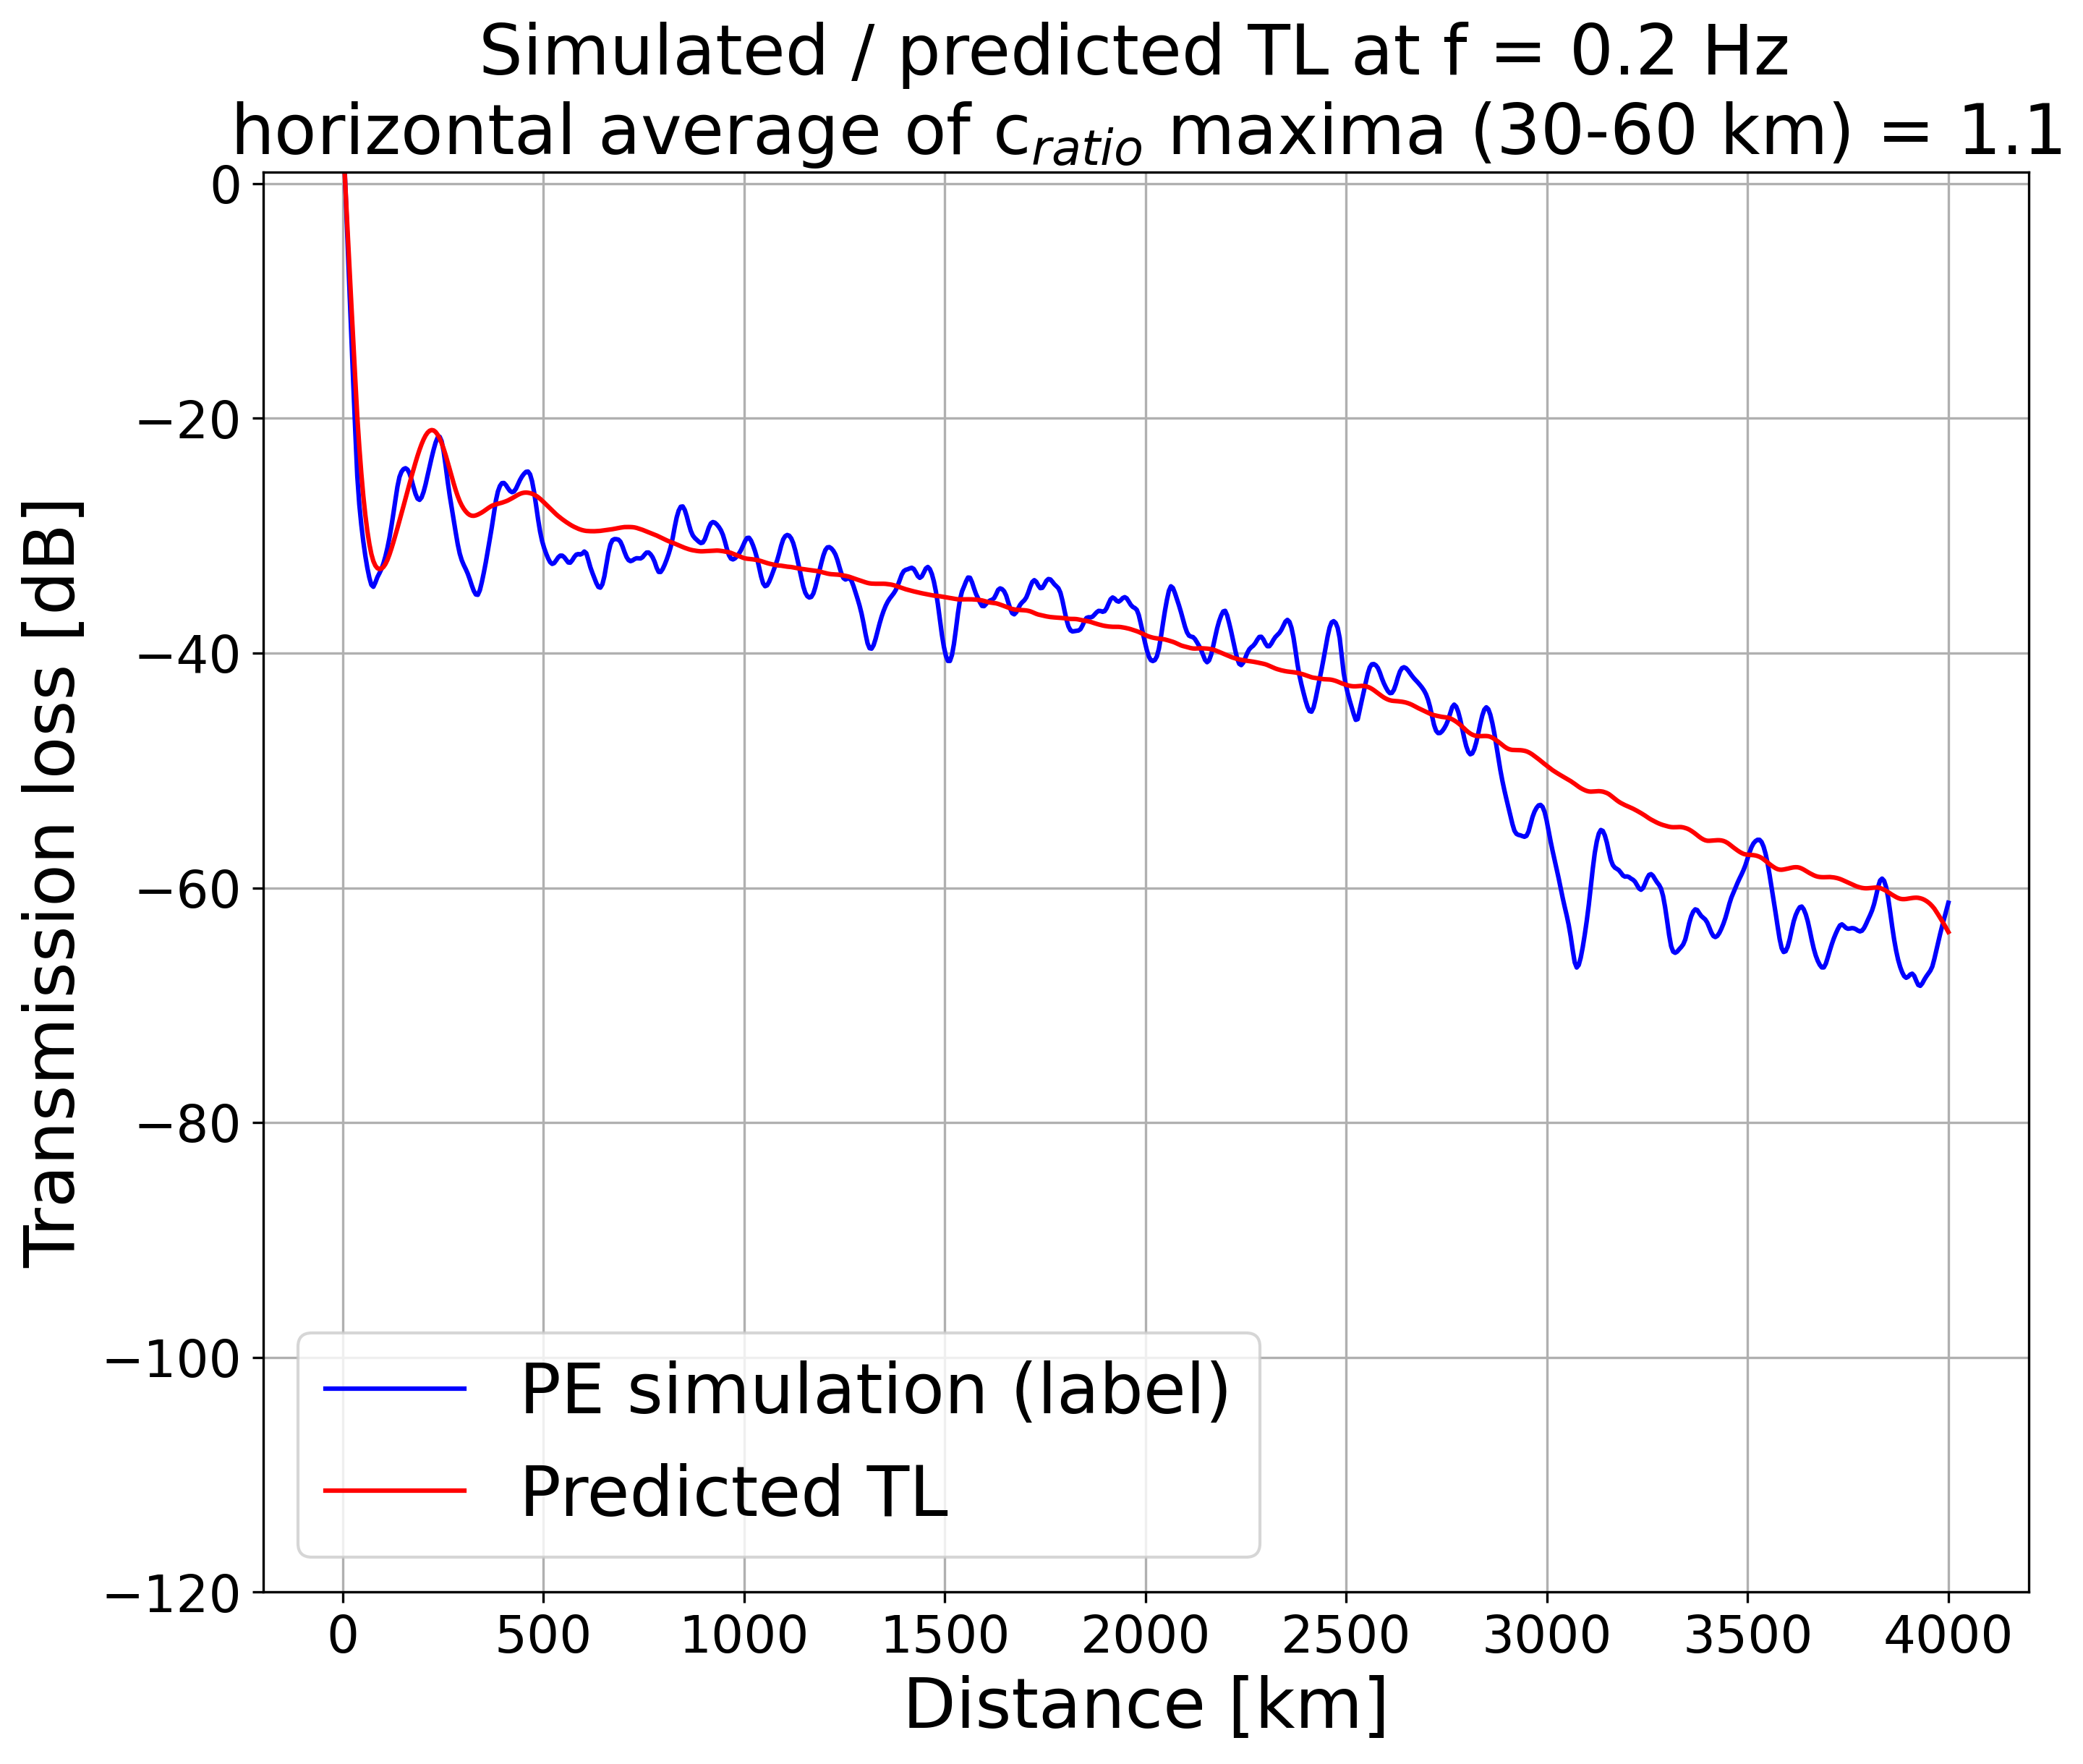

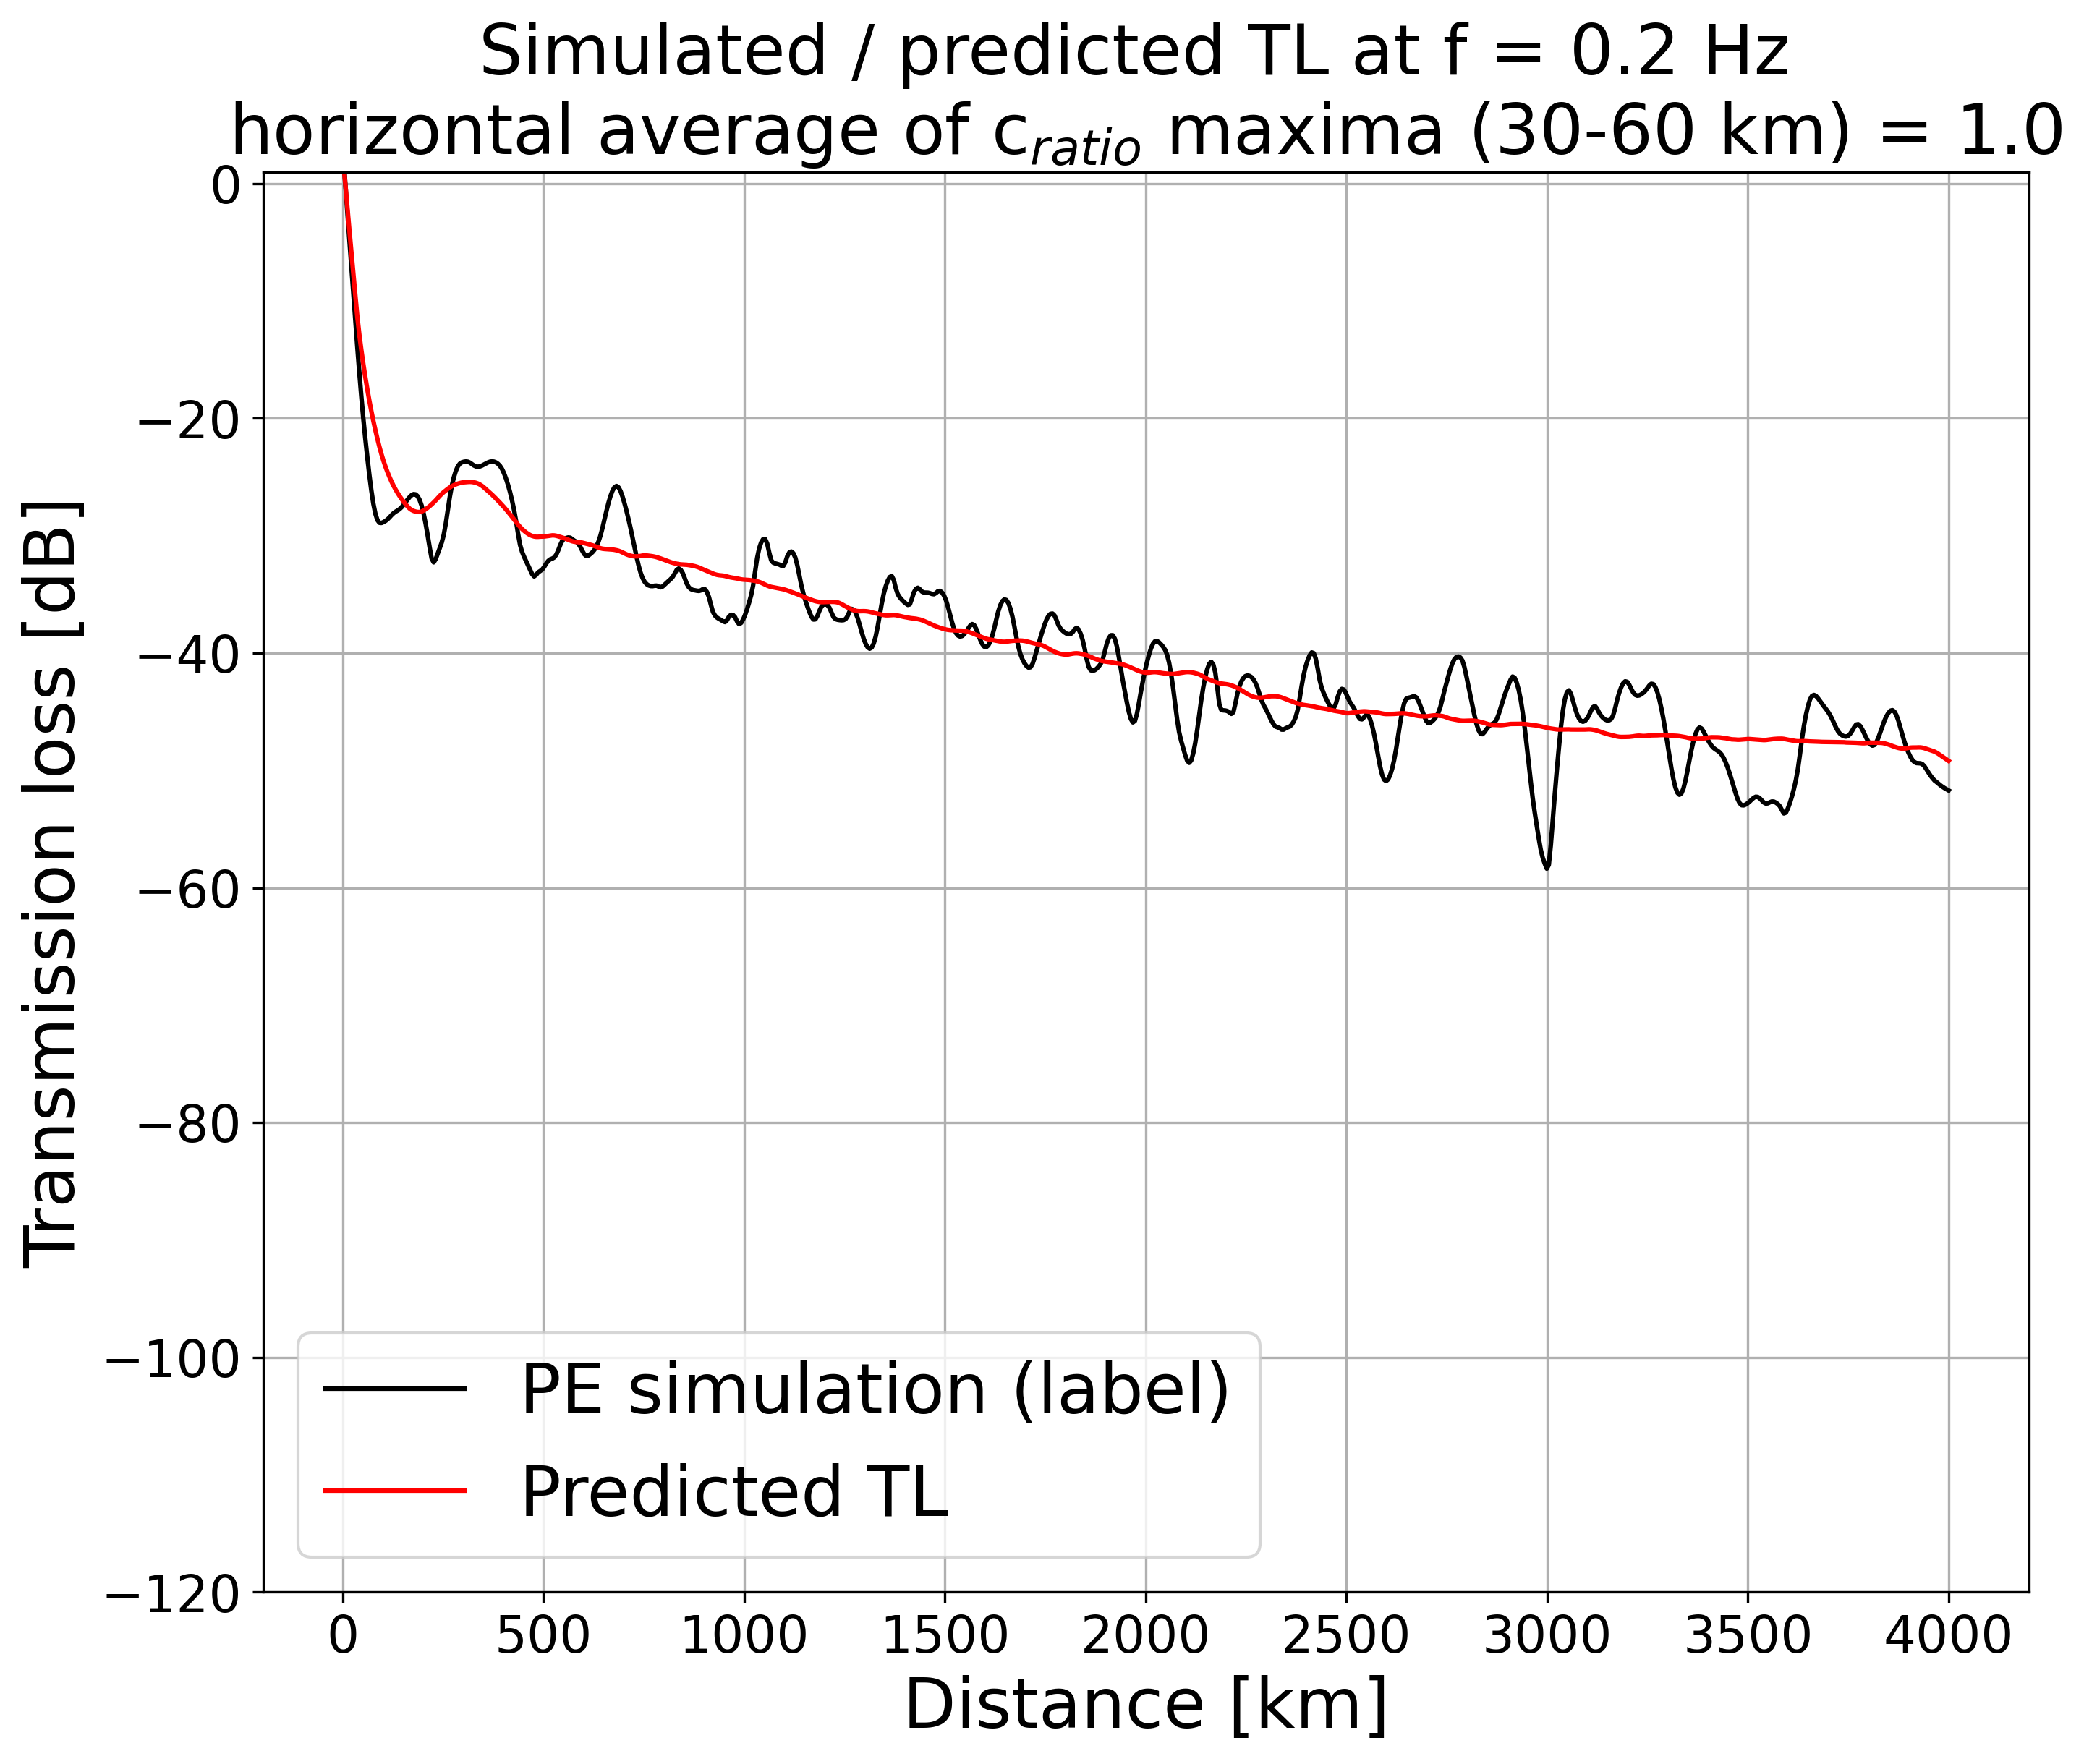

In [15]:
nb_samples = 2
for sample in range(nb_samples): # c_ratios.shape[0]   
    color=''
    if(horizontally_averaged_c_ratios_maxima_30_60[sample,:] > 1): # upwind conditions
        color='b'
    else: # downwind conditions
        color='k'
    plt.figure(figsize=(10.5,8.5), dpi=300)
    plt.plot(distance_PE, PE_simulations[sample], color=color, label='PE simulation (label)')
    plt.plot(distance_PE, predicted_TLs[sample], color='red', label='Predicted TL')
    plt.title("Simulated / predicted TL at f = "+str(np.around(freqs_test[sample,0,0],1))+" Hz \nhorizontal average of c$_{ratio}$ maxima (30-60 km) = " + str(np.round_(horizontally_averaged_c_ratios_maxima_30_60[sample,0], decimals = 1)), fontsize=23)
    plt.xlabel('Distance [km]', fontsize=23)
    plt.ylabel('Transmission loss [dB]', fontsize=23)
    plt.xticks(fontsize = 17)
    plt.yticks(fontsize = 17)
    plt.ylim(-120,1)
    plt.grid() 
    plt.legend(loc="lower left", fontsize=23)
    plt.show()
    plt.close()
    print("\n")